HỆ THỐNG TƯ VẤN - PHƯƠNG PHÁP CONTENT-BASED (ITEM TO ITEM)

In [1]:
from pymongo import MongoClient
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np 
from nltk.stem import PorterStemmer
import re

GIAI ĐOẠN 1: TRUY XUẤT DỮ LIỆU TỪ BIGQUERY

In [2]:
import bigframes.pandas as bf

bf.options.bigquery.location = "US" #this variable is set based on the dataset you chose to query
bf.options.bigquery.project = "project2-423018" #this variable is set based on the dataset you chose to query

In [3]:
initial_df = bf.read_gbq("project2-423018.glamira_dataset_models.Hybrid") #this variable is set based on the dataset you chose to query

GIAI ĐOẠN 2: EDA - TIỀN XỬ LÍ DỮ LIỆU

Bước 1: Tìm Hiểu Sơ Lược Về Dữ Liệu

In [6]:
# dataframe trích xuất từ MongoDB
initial_df.head()

,final_product_id,option,collection,final_price,product_name
0,80261,"[{'option_label': 'alloy', 'option_id': '45841', 'value_id': '204363'}]",view_product_detail,0.0,Wedding Ring Brilliant Couple
1,80261,"[{'option_label': 'alloy', 'option_id': '45841', 'value_id': '204363'}]",view_product_detail,0.0,Wedding Ring Brilliant Couple
2,80261,[],checkout,0.0,Wedding Ring Brilliant Couple
3,80261,[],view_shopping_cart,0.0,Wedding Ring Brilliant Couple
4,80261,[],checkout_success,0.0,Wedding Ring Brilliant Couple


In [7]:
# kiểu dữ liệu các cột của initial_df
initial_df.dtypes

final_product_id     object
option               object
collection           object
final_price         float64
product_name         object
dtype: object

In [8]:
# Danh sách giá trị duy nhất của cột 'collection'
initial_df['collection'].unique()

array(['view_product_detail', 'checkout', 'view_shopping_cart',
       'checkout_success', 'select_product_option_quality',
       'select_product_option', 'add_to_cart_action',
       'back_to_product_action'], dtype=object)

In [9]:
# Số lượng 'final_product_id' có trong dữ liệu, mỗi 'final_product_id' là một sản phẩm cố định
initial_df['final_product_id'].nunique()

12645

In [10]:
# Số lượng hành động đã mua hàng thành công
count_CheckoutSuccess = (initial_df['collection'] == 'checkout_success').sum()
print(f"Số lượng đơn hàng thành công: {count_CheckoutSuccess}")

# Tính tổng số dòng dữ liệu
total_rows = len(initial_df)

# Tính tỷ lệ phần trăm hành động 'checkout_success'
CheckoutSuccess_percentage = (count_CheckoutSuccess / total_rows) * 100

# In kết quả
print(f"Tỉ lệ đơn hàng thành công trong tập dữ liệu: ({CheckoutSuccess_percentage:.2f}%)")

Số lượng đơn hàng thành công: 18000
Tỉ lệ đơn hàng thành công trong tập dữ liệu: (1.92%)


Bước 2: Tiền Xử Lí Dữ Liệu

In [11]:
# Xóa một số tương tác không có ý nghĩa với sản phẩm
initial_df = initial_df[~initial_df['final_product_id'].isin(['103896', '97507'])]

- 1. Xử lí cột 'final_price'

In [12]:
# phân tích sơ lược cột 'final_price'
# Tính số dòng thiếu giá (null, rỗng, hoặc bằng 0)
num_missing_final_price = (
    initial_df['final_price'].isna().sum() +
    (initial_df['final_price'] == '').sum() +
    (initial_df['final_price'] == 0).sum()
)

print(f"Số lượng dòng bị null, rỗng hoặc có giá trị 0 (ban đầu): {num_missing_final_price}")

# Tổng số dòng dữ liệu
total_rows = len(initial_df)

# Tính tỷ lệ phần trăm dòng thiếu giá
missing_percentage = (num_missing_final_price / total_rows) * 100

print(f"Tỉ lệ dữ liệu có 'final_price' bị thiếu giá sản phẩm (ban đầu): {missing_percentage:.2f}%")

Số lượng dòng bị null, rỗng hoặc có giá trị 0 (ban đầu): 915411
Tỉ lệ dữ liệu có 'final_price' bị thiếu giá sản phẩm (ban đầu): 98.22%


In [13]:
# Tạo DataFrame phụ lưu final_product_id và final_price với điều kiện giá trị hợp lệ
valid_price_df = initial_df[
    initial_df['final_product_id'].notna() & (initial_df['final_product_id'] != '') &
    initial_df['final_price'].notna() & (initial_df['final_price'] != '') &
    (initial_df['final_price'] != 0)
][['final_product_id', 'final_price']]

# Nếu muốn loại trùng lặp (chỉ lấy mỗi product_id 1 giá), bạn có thể dùng:
valid_price_df = valid_price_df.drop_duplicates(subset='final_product_id')

print(f"Tổng số sản phẩm có giá hợp lệ: {len(valid_price_df)}")

Tổng số sản phẩm có giá hợp lệ: 4279


In [14]:
# Tạo dictionary ánh xạ từ final_product_id → final_price
price_mapping = valid_price_df.set_index('final_product_id')['final_price'].to_dict()

# Hàm điền giá: chỉ thay nếu final_price bị thiếu, rỗng hoặc bằng 0
def fill_price(row):
    if pd.isna(row['final_price']) or row['final_price'] == '' or row['final_price'] == 0:
        return price_mapping.get(row['final_product_id'], row['final_price'])
    return row['final_price']

# Áp dụng hàm điền giá cho toàn bộ dataframe
initial_df['final_price'] = initial_df.apply(fill_price, axis=1)

# Kiểm tra kết quả
num_missing_final_price_after = (
    initial_df['final_price'].isna().sum() +
    (initial_df['final_price'] == '').sum() +
    (initial_df['final_price'] == 0).sum()
)

# Tính tỷ lệ phần trăm dòng thiếu giá
missing_percentage_after = (num_missing_final_price_after / total_rows) * 100

print(f"Tỉ lệ dữ liệu có 'final_price' bị thiếu giá sản phẩm (sau ánh xạ): {missing_percentage_after:.2f}%")

Tỉ lệ dữ liệu có 'final_price' bị thiếu giá sản phẩm (sau ánh xạ): 16.81%


In [15]:
# Điền các dòng vẫn còn bị thiếu giá sản phẩm bằng giá trị trung vị (median) của cột
price_median = initial_df['final_price'].median()
initial_df['final_price'] = initial_df['final_price'].apply(lambda x: price_median if pd.isna(x) or x == '' or x == 0 else x)
print(f"Đã xử lý cột 'final_price'. Giá trị trung vị để điền là: {price_median:.2f} USD")

Đã xử lý cột 'final_price'. Giá trị trung vị để điền là: 463.87 USD


In [16]:
initial_df['final_price'].describe()

count    9.319960e+05
mean     4.772314e+03
std      6.473193e+04
min      7.500000e+00
25%      3.745440e+02
50%      4.638700e+02
75%      9.328000e+02
max      9.813373e+06
Name: final_price, dtype: float64

In [17]:
# loại bỏ đi 1 phần outlier
q_low = initial_df['final_price'].quantile(0.05)
q_high = initial_df['final_price'].quantile(0.95)
filtered_df = initial_df[(initial_df['final_price'] >= q_low) & (initial_df['final_price'] <= q_high)]

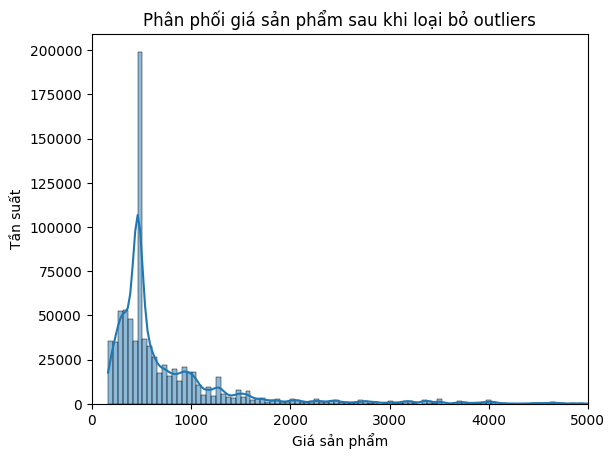

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(filtered_df['final_price'], bins=100, kde=True)
plt.xlim(0, 5000)  # zoom vào khoảng dưới 5000 để dễ xem
plt.title("Phân phối giá sản phẩm sau khi loại bỏ outliers")
plt.xlabel("Giá sản phẩm")
plt.ylabel("Tần suất")
plt.show()


📌 Nhận định quan trọng
Thị trường có mức giá chính phổ biến là thấp và trung bình:

~70–80% sản phẩm nằm dưới mức 1,000.

Đây là nhóm sản phẩm bình dân, có thể coi là mainstream segment.

Các sản phẩm cao cấp có giá trị cao nhưng ít:

- Các mức >2,000 là sản phẩm niche hoặc luxury → nên phân biệt rõ khi phân loại.
- Chia theo quartile (qcut) sẽ không hợp lý:
Vì số lượng sản phẩm rẻ rất nhiều → sẽ khiến các bin bị bóp méo hoặc mất ý nghĩa thực tế.
- Do đó nên chọn phương án định nghĩa thủ công

In [19]:
# Hướng tiếp cận tự định nghĩa price_bin
bins = [0, 300, 800, 2000, float('inf')]
labels = ['price_low', 'price_medium', 'price_high', 'price_premium']
initial_df['price_bin'] = pd.cut(initial_df['final_price'], bins=bins, labels=labels, right=False)

In [20]:
# phân bổ khoảng giá sản phẩm
initial_df['price_bin'].value_counts()

price_bin
price_medium     492381
price_high       184430
price_low        158291
price_premium     96894
Name: count, dtype: int64

- 2. xử lí cột 'collection'

In [21]:
# Tự tạo danh mục 'rating'
interaction_weights = {
    'checkout_success': 5.0,                # Tín hiệu cao nhất - thanh toán thành công
    'checkout': 4.0,                        # Bắt đầu thanh toán
    'add_to_cart_action': 3.0,              # Ý định mua rất cao - thêm sản phẩm vào giỏ hàng
    'select_product_option': 2.0,           # Quan tâm sâu - chọn tùy chọn cho sản phẩm
    'select_product_option_quality': 2.0,   # Quan tâm sâu - chọn tùy chọn cho sản phẩm
    'view_shopping_cart': 1.5,              # Xem giỏ hàng
    'back_to_product_action': 1.2,          # Quan tâm trở lại
    'view_product_detail': 1.0,             # Quan tâm cơ bản - trang chi tiết thông tin sản phẩm
}

In [22]:
initial_df['rating'] = initial_df['collection'].map(interaction_weights).fillna(0)
print("\nĐã cập nhật cột 'rating' với thang điểm mới.")
print("Phân bổ số lượng các loại rating mới:")
print(initial_df['rating'].value_counts())


Đã cập nhật cột 'rating' với thang điểm mới.
Phân bổ số lượng các loại rating mới:
rating
2.0    389983
1.0    276770
1.5    164589
4.0     64726
3.0     18873
5.0     17019
1.2        36
Name: count, dtype: int64


- 3. Tạo category sản phẩm

In [23]:
# Hàm phân loại category sản phẩm
# Các bước xử lý ngầm: kiểm tra các từ phổ biến trong tên sản phẩm -> đưa ra nhận định chủ quan các từ nào cùng thuộc một danh mục sản phẩm

def get_category_from_name(product_name):
    """
    Hàm nhận vào tên sản phẩm và trả về danh mục dựa trên bộ quy tắc đã được nâng cấp.
    Danh mục trả về sử dụng tiếng Anh.
    """
    # Bộ quy tắc nâng cấp, bao gồm cả từ khóa đa ngôn ngữ
    category_keywords = {
        'ring': [                                         # nhẫn
            'ring', 'rings', 'band',                      # Tiếng Anh
            'trauring', 'herrenring', 'damenring',        # Tiếng Đức
            'ehering', 'verlobungsring', 'ringe',         # Tiếng Đức
            'inel',                                       # Tiếng Rumani
            'bague', 'alliance',                          # Tiếng Pháp
            'vihkisormus',                                # Tiếng Phần Lan
            'anillo'                                      # Tiếng Tây Ban Nha
        ],
        'necklace': ['pendant', 'necklace', 'chain'],   # dây chuyền
        'earring': ['earring', 'earrings', 'studs'],    # bông tai
        'bracelet': ['bracelet', 'armband'],            # lắc tay
        'anklet': ['anklet'],                           # lắc chân
        'brooch': ['brooch'],                           # trâm cài áo
        'cufflinks': ['cufflinks', 'cufflink'],         # khuy áo
        'set': ['set'],                                 # bộ sản phẩm
        'kids': ['childrens', "children's", 'kids'],    # sản phẩm dành cho trẻ em
        'accessory': ['pin', 'tiepin']                  # phụ kiện 
    }

    # Kiểm tra input hợp lệ
    if not isinstance(product_name, str):
        return 'unknown'
    
    # Chuyển tên sản phẩm về chữ thường để tìm từ khóa
    name_lower = product_name.lower()

    # Duyệt qua từng danh mục và kiểm tra xem tên sản phẩm có chứa từ khóa nào không
    for category, keywords in category_keywords.items():
        for keyword in keywords:
            # Sử dụng regex để đảm bảo khớp từ đúng ranh giới từ (tránh match sai)
            if re.search(r'\b' + re.escape(keyword) + r'\b', name_lower):
                return category

    # Trường hợp không khớp với bất kỳ danh mục nào đã định nghĩa
    return 'other'  # danh mục khác


In [24]:
initial_df['category'] = initial_df['product_name'].apply(get_category_from_name)

# Kiểm tra lại kết quả phân bổ
print("\nPhân bổ số lượng tương tác theo 'category':")
print(initial_df['category'].value_counts())


Phân bổ số lượng tương tác theo 'category':
category
ring         644654
necklace     113258
earring       94478
other         42610
bracelet      27549
set            4465
accessory      1644
cufflinks      1161
anklet         1028
kids            742
brooch          407
Name: count, dtype: int64


In [25]:
print('Ma trận dữ liệu sau khi EDA')
initial_df.head()

Ma trận dữ liệu sau khi EDA


,final_product_id,option,collection,final_price,product_name,price_bin,rating,category
0,80261,"[{'option_label': 'alloy', 'option_id': '45841', 'value_id': '204363'}]",view_product_detail,323.4,Wedding Ring Brilliant Couple,price_medium,1.0,ring
1,80261,"[{'option_label': 'alloy', 'option_id': '45841', 'value_id': '204363'}]",view_product_detail,323.4,Wedding Ring Brilliant Couple,price_medium,1.0,ring
2,80261,[],checkout,323.4,Wedding Ring Brilliant Couple,price_medium,4.0,ring
3,80261,[],view_shopping_cart,323.4,Wedding Ring Brilliant Couple,price_medium,1.5,ring
4,80261,[],checkout_success,323.4,Wedding Ring Brilliant Couple,price_medium,5.0,ring


GIAI ĐOẠN 3: XÂY DỰNG MA TRẬN ĐẶC TRƯNG SẢN PHẨM

Xây dựng ma trận đặc trưng sản phẩm
- Mục tiêu: Xây dựng ma trận đặc trưng sản phẩm (product content matrix) dựa trên thông tin như tên sản phẩm, các tùy chọn, khoảng giá,…
- Giải pháp:
    + Mỗi sản phẩm có thể được mô tả bằng một tập hợp đặc trưng như: tên, option, khoảng giá,...
    + Từ các đặc trưng này → tạo một chuỗi mô tả đặc trưng duy nhất cho mỗi sản phẩm.
    + Biến các mô tả đó thành vector số bằng TF-IDF

In [26]:
# Stemming là một kỹ thuật trong xử lý ngôn ngữ tự nhiên (NLP) dùng để rút gọn một từ về "gốc từ" (stem)
stemmer = PorterStemmer()

if initial_df.empty:
    print("Không có dữ liệu nào được truy vấn. Các bước sau sẽ bị bỏ qua.")
    product_df = pd.DataFrame(columns=['final_product_id', 'features'])
    tfidf_matrix_products = None
    vectorizer = None
    product_indices = pd.Series(dtype='int64')
    user_profiles = {}
else:
    # Đổi tên cột
    rename_dict = {
        "collection": "interaction_type"
    }
    cols_to_rename = {k: v for k, v in rename_dict.items() if k in initial_df.columns}
    initial_df = initial_df.rename(columns=cols_to_rename)

    # Đảm bảo final_product_id là dạng chuỗi
    if 'final_product_id' in initial_df.columns:
        initial_df['final_product_id'] = initial_df['final_product_id'].astype(str)
    else:
        print("LỖI: Cột 'final_product_id' không được tìm thấy.")


    # Hàm xây dựng ma trận đặc trưng cho sản phẩm 'final_product_df'
    def tổng_hợp_đặc_trưng_sản_phẩm(row):
        features_list = []
        
        # 1. Feature từ 'product_name'
        # Thực hiện: chuẩn hóa về chữ thường -> loại bỏ kí tự đặc biệt -> chia nhỏ tên sản phẩm -> rút gọn về từ gốc
        if 'product_name' in row and pd.notna(row['product_name']):
            product_name_text = str(row['product_name']).lower()
            # Tiền xử lý tên sản phẩm
            product_name_text = re.sub(r'[^\w\s]', '', product_name_text)   
            product_name_terms = product_name_text.split()
            for term in product_name_terms:
                if term.strip():
                    stemmed_term = stemmer.stem(term.strip())
                    features_list.append(f"name_{stemmed_term}")
            # ví dụ: "Engagement ring Marica" → "engagement ring marica" -> ['name_engag', 'name_ring', 'name_marica']


        # 2. Feature từ 'option' 
        # Thực hiện: chuẩn hóa về chữ thường -> loại bỏ khoảng trắng -> rút gọn về từ gốc (chỉ trích xuất option_label)
        # ví dụ: option_label: "alloy" -> ['opt_alloy']
        if 'option' in row and isinstance(row['option'], list):
            for option_dict in row['option']:
                if isinstance(option_dict, dict):
                    label = option_dict.get('option_label')
                    value_id = option_dict.get('value_id') # Lấy thêm value_id
                    
                    if label and str(label).strip():
                        clean_label = str(label).strip().lower().replace(' ', '_').replace('/', '_')
                        stemmed_label = stemmer.stem(clean_label)
                        
                        if value_id and str(value_id).strip():
                            # Tạo đặc trưng kết hợp chi tiết, ví dụ: opt_alloy_204363
                            feature = f"opt_{stemmed_label}_{str(value_id).strip()}"
                            features_list.append(feature)
                        else:
                            # Giữ lại đặc trưng chung nếu không có value_id
                            feature = f"opt_{stemmed_label}"
                            features_list.append(feature)
        

        # 3. Feature từ 'price_bin' (khoảng giá)
        if 'price_bin' in row and pd.notna(row['price_bin']):
            features_list.append(str(row['price_bin']))


        # 4. Feature từ 'category'
        if 'category' in row and pd.notna(row['category']):
            features_list.append(f"cat_{str(row['category'])}")    

        return ' '.join(features_list)

In [27]:
# Tạo đặc trưng sản phẩm
initial_df["combined_features_temp"] = initial_df.apply(tổng_hợp_đặc_trưng_sản_phẩm, axis=1)

# loại bỏ dòng không có mô tả sản phẩm
initial_df = initial_df[initial_df["combined_features_temp"].str.strip() != '']

In [28]:
# hàm gom đặc trưng mô tả sản phẩm thành một chuỗi duy nhất
def aggregate_unique_features(series_of_feature_strings): 
    all_features = []
    for feature_string in series_of_feature_strings:
        if str(feature_string).strip(): all_features.extend(feature_string.split(' '))
    return ' '.join(sorted(list(set(all_features))))
        
# hàm gom option sản phẩm
def aggregate_options(series_of_options):
    all_option_labels = []
    for option_list in series_of_options:
        if isinstance(option_list, list):
            for opt in option_list:
                label = opt.get('option_label')
                if label and isinstance(label, str) and label.strip():
                    all_option_labels.append(label.strip().lower())
    # sắp xếp
    return sorted(set(all_option_labels))

In [29]:
# Tạo dataframe sản phẩm
product_df = initial_df.groupby("final_product_id", as_index=False).agg(
    # Lấy product_name trực tiếp trong lúc groupby
    product_name=('product_name', 'first'), 
    option=('option', aggregate_options),
    category=('category', 'first'),
    features=('combined_features_temp', aggregate_unique_features),
    final_price=('final_price', 'first'),
    price_bin=('price_bin', 'first')
)

# Sắp xếp lại cột cho đúng thứ tự
product_df = product_df[['final_product_id', 'product_name', 'category', 'option', 'final_price', 'price_bin', 'features']]
product_df = product_df[product_df["features"].str.strip() != ""].reset_index(drop=True)
print(f"Số lượng sản phẩm có đặc trưng trong product_df: {len(product_df)}")

Số lượng sản phẩm có đặc trưng trong product_df: 12643


In [30]:
# Kiểm tra phân bổ category
print("\nPhân bổ số lượng sản phẩm theo category:")
print(product_df['category'].value_counts())


Phân bổ số lượng sản phẩm theo category:
category
ring         7871
necklace     1533
other        1387
earring      1149
bracelet      452
cufflinks      83
anklet         43
accessory      35
set            31
brooch         30
kids           29
Name: count, dtype: int64


In [31]:
# Tạo ma trận TF-IDF

if not product_df.empty and "features" in product_df.columns and product_df["features"].notna().any():
    '''Khởi tạo TfidfVectorizer:
    stop_words='english': loại bỏ các từ dừng (ví dụ: 'the', 'is', 'with'…)
    min_df=6: chỉ giữ lại các từ xuất hiện trong ít nhất 6 sản phẩm (tương ứng khoảng 0.05% số lượng sản phẩm)
    ngram_range=(1, 2): lấy cả unigram (từng từ) và bigram (cặp từ liên tiếp)
    '''
    vectorizer = TfidfVectorizer(stop_words='english', min_df=6, ngram_range=(1, 2))
    
    # Huấn luyện vectorizer và biến đổi cột 'features' thành ma trận TF-IDF
    tfidf_matrix_products = vectorizer.fit_transform(product_df["features"])

    # In kích thước của ma trận: (số sản phẩm, số đặc trưng TF-IDF)
    print(f"Ma trận TF-IDF sản phẩm có hình dạng: {tfidf_matrix_products.shape}")

    # Đảm bảo cột 'final_product_id' là kiểu chuỗi (string) để sử dụng làm index tra cứu
    product_df['final_product_id'] = product_df['final_product_id'].astype(str)

    # Tạo Series ánh xạ từ final_product_id → chỉ số dòng trong product_df
    # Mục đích: tra cứu nhanh sản phẩm theo ID
    product_indices = pd.Series(product_df.index, index=product_df["final_product_id"]).drop_duplicates()

else:
    print("Không có đặc trưng sản phẩm hợp lệ để tính TF-IDF.")
    tfidf_matrix_products, vectorizer, product_indices = None, None, pd.Series(dtype='int64')

Ma trận TF-IDF sản phẩm có hình dạng: (12643, 1733)


In [32]:
print("--- Hoàn thành Giai đoạn 3 ---")
if 'initial_df' in locals() and not initial_df.empty: print(f"initial_df sau Giai đoạn 1: {len(initial_df)} dòng")
else: print("initial_df rỗng hoặc chưa được tạo sau Giai đoạn 3.")
if 'product_df' in locals(): print(f"product_df sau Giai đoạn 3: {len(product_df)} dòng")
else: print("product_df chưa được tạo.")
print("-" * 50)

--- Hoàn thành Giai đoạn 3 ---
initial_df sau Giai đoạn 1: 931996 dòng
product_df sau Giai đoạn 3: 12643 dòng
--------------------------------------------------


Supervised Feature Weighting dùng Normalized Deviation
- Ý tưởng: Chuyển từ "Từ nào xuất hiện?" sang "Từ nào quan trọng?"
    + Các phương pháp trước đó như TF-IDF chỉ trả lời câu hỏi: "Một từ có hiếm và xuất hiện nhiều trong một sản phẩm không?"
    + Phương pháp TF-IDF hoàn toàn không giám sát (unsupervised), tức là không hề biết đến hành vi hay sở thích của người dùng.
    + Từ đó triển khai hướng tiếp cận thuộc nhóm Gán trọng số Đặc trưng có Giám sát (Supervised Feature Weighting).

- Mục tiêu chính: 
    + Không phải tất cả các từ đặc trưng đều có giá trị như nhau
    + Tìm và định lượng mức độ quan trọng của mỗi từ.

- Ý nghĩa: Một từ đặc trưng "tốt" là từ có khả năng phân biệt mạnh mẽ giữa các tương tác có mức độ quan tâm cao và các tương tác có mức độ quan tâm thấp.

- Phương pháp tiếp cận: Độ lệch Chuẩn hóa (Normalized Deviation)
    + Các thước đo thường được sử dụng: Gini, Entropy, Chi-squared, Normalized Deviation
    + Lý do: Normalized Deviation được thiết kế riêng cho các trường hợp mà "xếp hạng" (rating) là các giá trị số có thứ tự, chứ không chỉ là các nhãn phân loại đơn thuần.

In [33]:
# Supervised Feature Weighting dùng Normalized Deviation
''' Quy trình:
- Tính độ lệch chuẩn sigma của cột rating (chỉ tính rating > 0).

- Chia dữ liệu thành 2 nhóm:
Nhóm A (mu⁺): Các dòng có chứa từ w
Nhóm B (mu⁻): Các dòng không chứa từ w
-> Tính trung bình rating của mỗi nhóm

- Tính trọng số cho từ w: Trọng số từ = Độ lệch chuẩn hóa của rating giữa nhóm có/không có từ đó

Kết quả: Trọng số càng cao → từ đó càng có ảnh hưởng đến phân biệt hành vi người dùng.
'''

print("--- Bắt đầu Bước: Tính toán Trọng số Đặc trưng có Giám sát ---")
if 'initial_df' in locals() and 'vectorizer' in locals() and vectorizer is not None:
    # 1. Lấy toàn bộ từ vựng từ TfidfVectorizer
    try:
        vocabulary = vectorizer.get_feature_names_out()
    except AttributeError:
        # Fallback cho phiên bản sklearn cũ hơn
        vocabulary = vectorizer.get_feature_names()
        
    print(f"Tổng số từ trong từ vựng: {len(vocabulary)}")

    # 2. Tính độ lệch chuẩn toàn cục (sigma) của cột 'rating'
    # Chỉ tính trên các rating > 0 (các tương tác hợp lệ)
    valid_ratings = initial_df[initial_df['rating'] > 0]['rating']
    sigma = valid_ratings.std()
    print(f"Độ lệch chuẩn (sigma) của rating: {sigma:.4f}")

    # 3. Tính toán Normalized Deviation cho mỗi từ
    feature_weights = {}
    
    print("Đang tính toán Normalized Deviation cho từng từ...")
    # Chuyển cột 'combined_features_temp' thành một set các từ để tra cứu nhanh hơn
    # Điều này tối ưu hóa hiệu năng đáng kể so với việc dùng str.contains() lặp đi lặp lại
    features_as_sets = initial_df['combined_features_temp'].str.split().apply(set)

    for i, word in enumerate(vocabulary):
        if (i + 1) % 500 == 0:
            print(f"Đã xử lý {i+1}/{len(vocabulary)} từ...")
            
        # Mask để xác định các dòng chứa từ hiện tại một cách hiệu quả
        contains_word_mask = features_as_sets.apply(lambda x: word in x)
        
        # Lấy ra các rating tương ứng
        ratings_with_word = initial_df.loc[contains_word_mask, 'rating']
        ratings_without_word = initial_df.loc[~contains_word_mask, 'rating']

        # Tính mu+ và mu-
        mu_plus = ratings_with_word.mean() if not ratings_with_word.empty else 0
        mu_minus = ratings_without_word.mean() if not ratings_without_word.empty else 0

        # Tính Normalized Deviation
        if sigma > 0:
            dev_w = abs(mu_plus - mu_minus) / sigma
            feature_weights[word] = dev_w
        else:
            feature_weights[word] = 0

    # Sắp xếp các trọng số để xem kết quả
    sorted_weights = sorted(feature_weights.items(), key=lambda item: item[1], reverse=True)

    print("\n--- Kết quả Normalized Deviation ---")
    print("Top 5 từ có tính phân biệt CAO NHẤT:")
    for word, weight in sorted_weights[:5]:
        print(f"- '{word}': {weight:.4f}")

    print("\nTop 5 từ có tính phân biệt THẤP NHẤT:")
    for word, weight in sorted_weights[-5:]:
        print(f"- '{word}': {weight:.4f}")
        
else:
    print("Không đủ dữ liệu ('initial_df', 'vectorizer') để tính toán trọng số đặc trưng.")
    feature_weights = {}

--- Bắt đầu Bước: Tính toán Trọng số Đặc trưng có Giám sát ---
Tổng số từ trong từ vựng: 1733
Độ lệch chuẩn (sigma) của rating: 0.8799
Đang tính toán Normalized Deviation cho từng từ...
Đã xử lý 500/1733 từ...
Đã xử lý 1000/1733 từ...
Đã xử lý 1500/1733 từ...

--- Kết quả Normalized Deviation ---
Top 5 từ có tính phân biệt CAO NHẤT:
- 'cat_accessory name_glamira': 2.0783
- 'cat_anklet name_anklet': 2.0783
- 'cat_bracelet name_16': 2.0783
- 'cat_bracelet name_20': 2.0783
- 'cat_bracelet name_ankl': 2.0783

Top 5 từ có tính phân biệt THẤP NHẤT:
- 'price_high': 0.0013
- 'name_016': 0.0008
- 'name_kihlasormu': 0.0002
- 'name_allianc': 0.0001
- 'name_aura': 0.0001


In [34]:
# Áp dụng Trọng số để tạo Ma trận TF-IDF mới
# Ý tưởng là sẽ nhân mỗi cột trong ma trận TF-IDF (tương ứng với một từ) với điểm Normalized Deviation của từ đó

print("--- Bắt đầu: Tạo Ma trận TF-IDF có Trọng số (Weighted TF-IDF) ---")

if 'tfidf_matrix_products' in locals() and tfidf_matrix_products is not None and \
   'vectorizer' in locals() and vectorizer is not None and \
   'feature_weights' in locals() and feature_weights:

    # 1. Tạo một vector trọng số có thứ tự khớp với từ vựng của vectorizer
    # Lấy từ điển từ vựng: {'tên_từ': chỉ_số_cột}
    vocabulary_dict = vectorizer.vocabulary_
    
    # Khởi tạo vector trọng số với giá trị 1 (mặc định không thay đổi)
    # Kích thước của nó bằng với số lượng từ trong từ vựng
    weighted_vector = np.ones(len(vocabulary_dict))

    # 2. Điền trọng số đã tính vào đúng vị trí trong vector
    for word, weight in feature_weights.items():
        if word in vocabulary_dict:
            # Lấy chỉ số của từ
            word_index = vocabulary_dict[word]
            # Gán trọng số đã tính vào đúng vị trí
            weighted_vector[word_index] = weight

    # 3. Nhân ma trận TF-IDF với vector trọng số
    # Thao tác này sẽ nhân mỗi cột của ma trận với trọng số tương ứng
    # toarray() để chuyển thành mảng dày trước khi nhân, rồi chuyển lại sparse
    from scipy.sparse import csr_matrix
    weighted_tfidf_matrix_products = csr_matrix(tfidf_matrix_products.toarray() * weighted_vector)
    
    print(f"Đã tạo ma trận TF-IDF có trọng số với hình dạng: {weighted_tfidf_matrix_products.shape}")

else:
    print("Không đủ dữ liệu để tạo ma trận TF-IDF có trọng số. Sẽ sử dụng ma trận gốc.")
    weighted_tfidf_matrix_products = tfidf_matrix_products

--- Bắt đầu: Tạo Ma trận TF-IDF có Trọng số (Weighted TF-IDF) ---
Đã tạo ma trận TF-IDF có trọng số với hình dạng: (12643, 1733)


GIAI ĐOẠN 4: XÂY DỰNG HÀM GỢI Ý

- Nền tảng chung: không gian Vector và Độ tương đồng Cosine
Hãy tưởng tượng tất cả các đặc trưng sản phẩm (name_ring, price_high, region_0, ...) là các chiều trong một không gian đa chiều khổng lồ.
    + Mỗi sản phẩm giờ là một điểm (vector) trong không gian này.
    + Mỗi hồ sơ người dùng cũng là một điểm (vector) trong chính không gian đó.
    + Khi cả người dùng và sản phẩm đều ở trên cùng một "bản đồ", chúng ta có thể đo khoảng cách hoặc góc giữa chúng. Công cụ chúng ta sử dụng để đo lường chính là Độ tương đồng Cosine (Cosine Similarity).

- Ý tưởng của Cosine Similarity (đo góc giữa hai vector): 
    + Nếu hai vector chỉ về cùng một hướng (góc gần bằng 0), độ tương đồng của chúng sẽ gần bằng 1. 
    + Nếu chúng vuông góc (không liên quan), độ tương đồng sẽ gần bằng 0.

- Cosine Similarity hoạt động rất hiệu quả với dữ liệu văn bản (như các đặc trưng sản phẩm) vì nó không quan tâm đến "độ lớn" của vector mà chỉ quan tâm đến "hướng" của chúng. Điều này có nghĩa là một bài mô tả sản phẩm ngắn nhưng có cùng chủ đề với một bài mô tả dài vẫn có thể được coi là rất tương đồng.

Gợi ý "Sản phẩm cho Sản phẩm" (Item-to-Item Recommendation)
- Mục tiêu: Với một sản phẩm cho trước, tìm ra những sản phẩm khác có nội dung tương tự nhất.
- Quy trình thực hiện:
    + Lấy Dữ liệu: Chọn một sản phẩm gốc, và lấy ra vector đặc trưng của sản phẩm này từ ma trận weighted_tfidf_matrix_products.
    + Tính toán Độ tương đồng: Tính độ tương đồng cosine giữa vector của sản phẩm này với tất cả các vector sản phẩm khác trong cùng ma trận weighted_tfidf_matrix_products. (Trong thực tế, chúng ta thường tính trước một ma trận tương đồng item-item lớn bằng cosine_similarity(matrix, matrix) để tăng tốc độ).
    + Xếp hạng: Kết quả là một danh sách điểm số. Chúng ta cũng sắp xếp danh sách này từ cao xuống thấp.
- Lọc và Trả về:
    + Kết quả cao nhất luôn là chính product_X (với điểm tương đồng là 1.0). Chúng ta phải loại bỏ sản phẩm này.
    + Lấy ra top N (ví dụ: 5) sản phẩm tiếp theo trong danh sách để gợi ý.

In [52]:
# Hàm gợi ý sản phẩm tương tự (Item-to-Item)
def get_similar_items(product_id_input, product_df_ref, item_item_sim_matrix, product_indices_map_ref, top_n=5):
    product_id_input_str = str(product_id_input) 
    if product_id_input_str not in product_indices_map_ref:
        print(f"Sản phẩm {product_id_input_str} không tìm thấy trong ánh xạ chỉ số.")
        return pd.DataFrame()
    if item_item_sim_matrix is None or item_item_sim_matrix.shape[0] == 0:
        print(f"Ma trận tương đồng item-item rỗng, không thể tạo gợi ý.")
        return pd.DataFrame()
    # Kiểm tra các cột cần thiết
    required_cols = ['final_product_id', 'product_name', 'option']
    if not all(col in product_df_ref.columns for col in required_cols):
        print(f"product_df_ref thiếu các cột cần thiết. Yêu cầu có: {required_cols}")
        return pd.DataFrame()

    idx = product_indices_map_ref[product_id_input_str]
    if idx >= item_item_sim_matrix.shape[0]: 
        print(f"Chỉ số {idx} cho sản phẩm {product_id_input_str} nằm ngoài phạm vi ma trận tương đồng.")
        return pd.DataFrame()

    sim_scores = list(enumerate(item_item_sim_matrix[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    recommended_items_output = []
    for i, score in sim_scores[1:]: 
        if len(recommended_items_output) == top_n:
            break
        if i < len(product_df_ref): 
            recommended_pid = str(product_df_ref.iloc[i]["final_product_id"]) 
            if recommended_pid != product_id_input_str: 
                # --- Lấy thêm thông tin chi tiết từ product_df_ref ---
                recommended_items_output.append({
                    "final_product_id": recommended_pid,
                    "product_name": product_df_ref.iloc[i]["product_name"], # Lấy tên sản phẩm
                    "category": product_df_ref.iloc[i]["category"], # Lấy thông tin category
                    "option": product_df_ref.iloc[i]["option"], # Lấy thông tin option
                    "final_price": product_df_ref.iloc[i]["final_price"], # lấy thông tin giá
                    "price_bin": product_df_ref.iloc[i]["price_bin"],   # lấy thông tin khoảng giá
                    "similarity_score": score
                })

    # Trả về DataFrame với các cột mong muốn
    if recommended_items_output:
        return pd.DataFrame(recommended_items_output)
    else:
        return pd.DataFrame()

In [53]:
# Ma trận tương đồng
if 'product_df' in locals() and not product_df.empty and \
   'weighted_tfidf_matrix_products' in locals() and weighted_tfidf_matrix_products is not None and \
   'product_indices' in locals() and not product_indices.empty and \
   'initial_df' in locals() and not initial_df.empty:
        
    if not product_df.empty and 'final_product_id' in product_df.columns:
        # Tính ma trận tương đồng từ ma trận có trọng số
        cosine_sim_item_item = cosine_similarity(weighted_tfidf_matrix_products, weighted_tfidf_matrix_products)

else:
    print("Không đủ dữ liệu hoặc các bước trước đó có lỗi, không thể thực hiện tính độ tương đồng cosine cho ma trận đặc trưng sản phẩm")

GIAI ĐOẠN 5: KIỂM NGHIỆM MÔ HÌNH

In [58]:
# địa chỉ product_id thử nghiệm
test_product = np.random.choice(initial_df['final_product_id'].unique())   #random ngẫu nhiên

In [59]:
if not product_df["final_product_id"].empty: 
    if test_product:
        print(f"\n✅ Gợi ý các sản phẩm tương tự với sản phẩm: {test_product}")
        similar_items_df = get_similar_items(test_product, product_df, cosine_sim_item_item, product_indices, top_n=5)
                
    else:
        print("Không chọn được test_product_for_similarity hợp lệ.")


✅ Gợi ý các sản phẩm tương tự với sản phẩm: 97979


In [60]:
# thông tin sản phẩm thử nghiệm
product_df[product_df['final_product_id'] == test_product]

,final_product_id,product_name,category,option,final_price,price_bin,features
11228,97979,Natural Sensation 8 mm,other,[alloy],463.87,price_medium,cat_other name_8 name_mm name_natur name_sensat opt_alloy_1339407 opt_alloy_1339415 opt_alloy_1339430 price_medium


In [61]:
# Top 5 sản phẩm gợi ý trả về từ hàm gợi ý ItemToItem
print("\n✅ Thử Nghiệm Với Mô Hình Hybrid")
print(f"\n Gợi ý top 5 sản phẩm tương đồng với sản phẩm: {test_product}")
similar_items_df


✅ Thử Nghiệm Với Mô Hình Hybrid

 Gợi ý top 5 sản phẩm tương đồng với sản phẩm: 97979


,final_product_id,product_name,category,option,final_price,price_bin,similarity_score
0,105013,Natural Treasure 8 mm,other,[alloy],463.87,price_medium,0.999454
1,104971,Natural Square 8 mm,other,[alloy],463.87,price_medium,0.989174
2,98642,Shining Sculpture 8 mm,other,[alloy],463.87,price_medium,0.788022
3,105975,White Twinkle 8 mm,other,[alloy],463.87,price_medium,0.785749
4,98076,White Shell 8 mm,other,[alloy],463.87,price_medium,0.781476
